In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN,Bidirectional
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train),(x_test, y_test)= mnist.load_data()

In [3]:
x_train.shape 

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
print(y_test)

[7 2 1 ... 4 5 6]


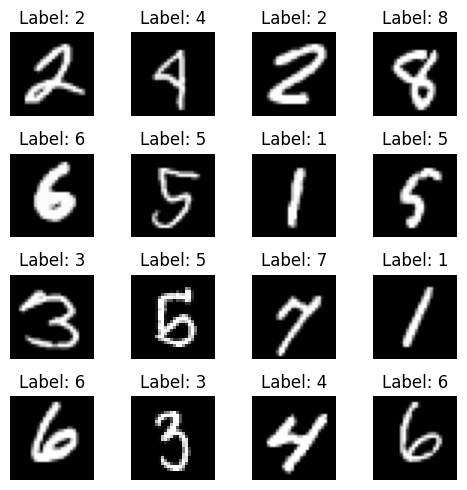

In [7]:
# Create a figure and subplots
import numpy as np
indices = np.random.randint(0, x_train.shape[0], size=16)
fig, axes = plt.subplots(4, 4, figsize=(5, 5)) # CREATE A FIG GRID 4x4

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, ax in enumerate(axes):
    image = x_train[indices[i]]
    label = y_train[indices[i]]
    ax.imshow(image, cmap='gray') # DISPLAY B&W
    ax.set_title(f"Label: {label}") # SHOW LABEL
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
x_train = x_train/255.0
x_test = x_test/255.0
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [9]:
model= Sequential()
model.add(Bidirectional(SimpleRNN(units=128, input_shape=(x_train.shape[1], x_train.shape[2]))))
model.add(Dense(10,activation='softmax'))

# simple RNN layer has 128 units and takes inputshape=(28,28) where 28 is the number
# of timestamp and each timestep has 28 features. 

c:\Users\divyadamodaran\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

In [11]:
history= model.fit(x_train,y_train, batch_size=128,epochs=3, validation_split=0.2)

Epoch 1/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8890 - loss: 0.3707 - val_accuracy: 0.9437 - val_loss: 0.1812
Epoch 2/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9523 - loss: 0.1567 - val_accuracy: 0.9622 - val_loss: 0.1272
Epoch 3/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9626 - loss: 0.1222 - val_accuracy: 0.9678 - val_loss: 0.1096


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (128, 256)             │        40,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (128, 10)              │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,288 (501.13 KB)

 Trainable params: 42,762 (167.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 85,526 (334.09 KB)

In [13]:
loss,acc=model.evaluate(x_test,y_test)
print('Test accuracy:',acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9676 - loss: 0.1115
Test accuracy: 0.9675999879837036


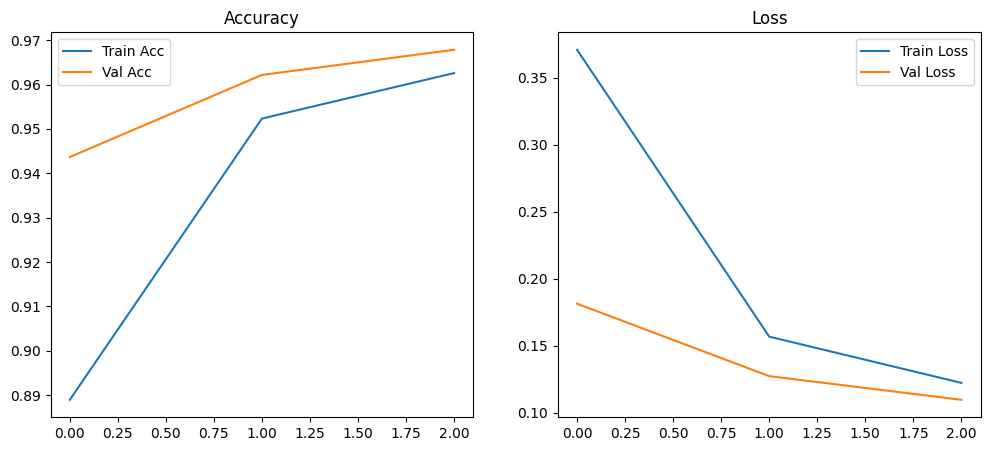

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Train Acc')
plt.plot(history.history['val_accuracy'],label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()